# Notebook for conducting the main sizing of the 5 design options for trade-off

In [8]:
import sys
import os
import matplotlib.pyplot as plt
import numpy.typing as nt
import aerosandbox.numpy as np

# Add the 'src' directory to the python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from src.Sizing_Loop.SizingForTradeoff import SizingForTradeoff, DesignOptionState

## Generating the initial values and decisions for design options

In [9]:
sizing_for_tradeoff = SizingForTradeoff()

for configuration in sizing_for_tradeoff.configurations:
    print()
    print(configuration.name)
    print("high wing" if np.isclose(configuration.wing_interference_factor, 1.) else "low wing")
    print("movable wing port" if configuration.main_wing_x_movable else "fixed wing port")
    print("canard capability" if configuration.canard_capability else "no canard port")
    print("sideways extending landing gear" if configuration.landing_gear_sideways_extendable else "downwards extending landing gear")


HUG-CFG-301
low wing
movable wing port
canard capability
sideways extending landing gear

HUG-CFG-302
high wing
fixed wing port
no canard port
downwards extending landing gear

HUG-CFG-303
high wing
fixed wing port
canard capability
sideways extending landing gear

HUG-CFG-304
high wing
movable wing port
canard capability
downwards extending landing gear

HUG-CFG-305
high wing
movable wing port
canard capability
sideways extending landing gear


## Specifying the settings of the analysis

In [10]:
sizing_for_tradeoff.accumulate_steps(debug=False)

In [11]:
def tracked_varaibles(state:DesignOptionState) -> nt.NDArray[np.float64]:
    return np.array([
        state.iterable.aircraft_parameters.total_mass
    ])

In [12]:
n_iterations = 8

## Running the analysis

In [13]:
sizing_results = sizing_for_tradeoff.size_options_for_tradeoff(n_iterations, tracked_varaibles)

print(sizing_results)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.40662310998264484
            Iterations: 7
            Function evaluations: 28
            Gradient evaluations: 7
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.45956338085904247
            Iterations: 7
            Function evaluations: 28
            Gradient evaluations: 7
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.42357674133565054
            Iterations: 7
            Function evaluations: 28
            Gradient evaluations: 7
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4447234141561455
            Iterations: 7
            Function evaluations: 28
            Gradient evaluations: 7
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.43167838135144976
            Iterations: 7
            Function evaluati

## Postprocessing the analysis

[[50.         25.91280329 49.50637023 32.25574292 41.70134478 35.66713833
  39.01101542 37.01649535 38.16309307]]
[[50.         23.19708334 47.5690338  28.73455225 39.33218348 32.06587926
  36.3304805  33.55745658 35.25200355]]
[[50.         24.77277355 48.73910937 30.81226614 40.80338759 34.26255019
  37.97200829 35.67694256 37.02737917]]
[[50.         25.91280329 49.63361252 32.25065334 41.78448304 35.67780348
  39.06801456 37.04041384 38.20831096]]
[[50.         25.91280329 49.45211206 32.23880781 41.67221716 35.64276835
  38.98642067 36.99075243 38.13873466]]


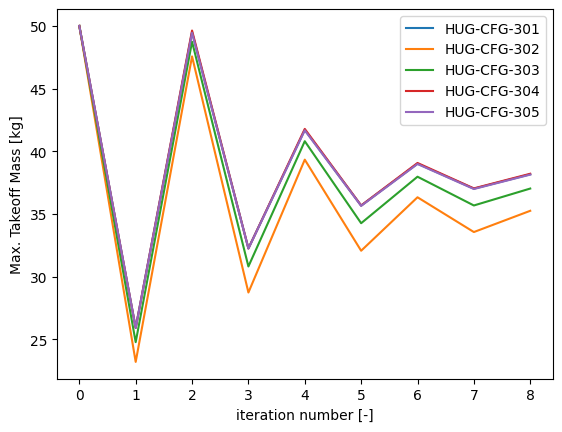

In [14]:
for design_option, convergence_history in sizing_results:
    print(convergence_history)
    print(design_option)
    plt.plot(list(range(n_iterations+1)), convergence_history[0], label=design_option.state.fixed.choices.name)
    
plt.ylabel("Max. Takeoff Mass [kg]")
plt.xlabel("iteration number [-]")
plt.legend()

In [ ]:
for design_option, convergence_history in sizing_results:
    print()
    print(design_option.state.fixed.choices.name)
    print(f"Landing gear nose x: {design_option.state.iterable.landing_gear.x_nose_lg}")
    print(f"Landing gear main x: {design_option.state.iterable.landing_gear.x_main_lg}")
    print(f"Main gear y: {design_option.state.iterable.landing_gear.y_main_lg}")
    print(f"MTOM: {design_option.state.iterable.aircraft_parameters.total_mass}")
    print(f"T/W: {design_option.state.iterable.aircraft_parameters.thrust_weight_ratio}")
    print(f"fuel fraction: {design_option.state.iterable.aircraft_parameters.fuel_mass_fraction}")
    # print(f"landing gear height: {design_option.state.iterable.landing_gear.length_z}")
    # print(f"Fuselage length: {design_option.state.total_fuselage_length()}")
    # print(f"Fus L1 {design_option.state.fixed.assumptions.fuselage_length1}")
    # print(f"Fus L2 {design_option.state.fixed.assumptions.fuselage_length2}")
    # print(f"Fus L3 {design_option.state.fixed.assumptions.fuselage_length3}")
    # print(f"Wingspan main wing: {design_option.state.iterable.lifting_surfaces[0].span}")
    # print(f"aspect ratio main wing: {design_option.state.iterable.lifting_surfaces[0].aspect_ratio}")
    # print(f"MTOM: {design_option.state.iterable.aircraft_parameters.total_mass}")


HUG-CFG-301
Landing gear nose x: 0.38691687834778765
Landing gear main x: 2.143180236230016
Main gear y: 0.3342311937756117
MTOM: 38.16309306753075
T/W: 0.3333656128421486

HUG-CFG-302
Landing gear nose x: 0.2724999999999023
Landing gear main x: 2.5701898394688443
Main gear y: 0.2314410906112883
MTOM: 35.25200355118611
T/W: 0.36237758446094004

HUG-CFG-303
Landing gear nose x: 0.272500000000135
Landing gear main x: 2.5701898394674263
Main gear y: 0.2314548754697476
MTOM: 37.02737916995261
T/W: 0.34307347902576707

HUG-CFG-304
Landing gear nose x: 0.2725000000007299
Landing gear main x: 2.5701898394638594
Main gear y: 0.23143255062331297
MTOM: 38.20831095859255
T/W: 0.33375398466089884

HUG-CFG-305
Landing gear nose x: 0.2725000000001778
Landing gear main x: 2.570189839467224
Main gear y: 0.23143496402419253
MTOM: 38.13873465954883
T/W: 0.3329107979363458
